In [1]:
# sphinx_gallery_thumbnail_number = 2
from eelbrain import *
import glob
import mne

In [2]:
subjs_all = glob.glob('./analysis/looming*-epo.fif')

event_dict = {
                '1001': 'Standard',
                '1002': 'Looming',
                '1003': 'Receding',
                '1004': 'Deviant'
            }

rows = []
for subj in subjs_all:
    for key, val in event_dict.items():
        subject = int(subj.split('-')[0][-3:])
        condition = val
        eeg = load.fiff.epochs_ndvar(mne.read_epochs(subj, verbose=False)[key], data='eeg')
        rows.append([subject, condition, eeg.mean('case')])

ds = Dataset.from_caselist(['subject', 'condition', 'eeg'], rows)
ds['subject'].random = True
print(ds.summary())

Key         Type     Values                                          
---------------------------------------------------------------------
subject     Var      2 - 18                                          
condition   Factor   Deviant:15, Looming:15, Receding:15, Standard:15
eeg         NDVar    64 sensor, 701 time; -8.32448e-06 - 1.67837e-05 
---------------------------------------------------------------------
Dataset: 60 cases


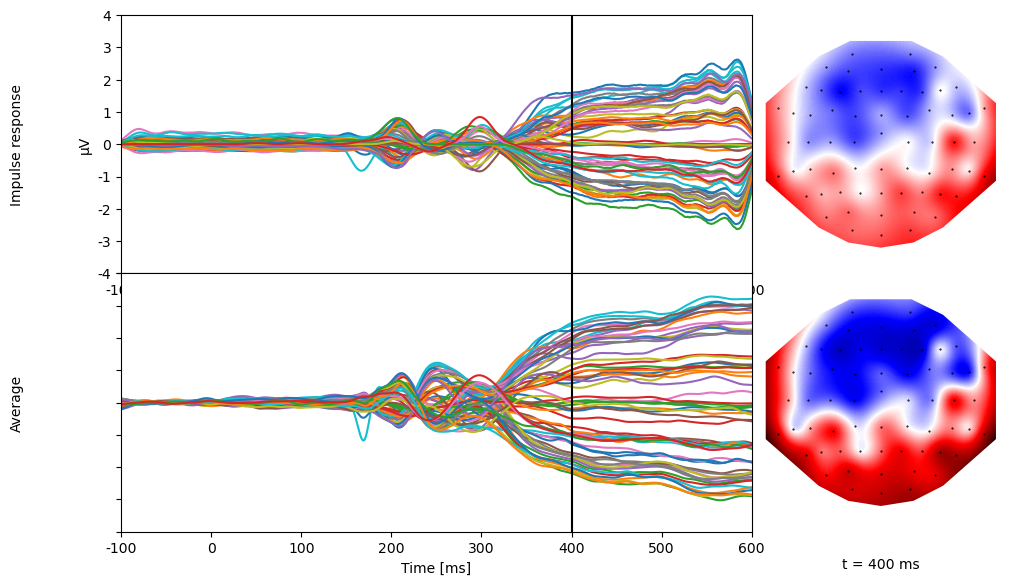

In [3]:
any_trial = epoch_impulse_predictor('eeg', 1, ds=ds)
fit = boosting('eeg', any_trial, -0.100, 0.600, basis=0.050, ds=ds, partitions=2, delta=0.01)
average = ds['eeg'].mean('case')
trf = fit.h.sub(time=(average.time.tmin, average.time.tstop))
p = plot.TopoButterfly([fit.h_scaled, average], xlim=(-0.100, 0.600), axtitle=['Impulse response', 'Average'], t=0.400)

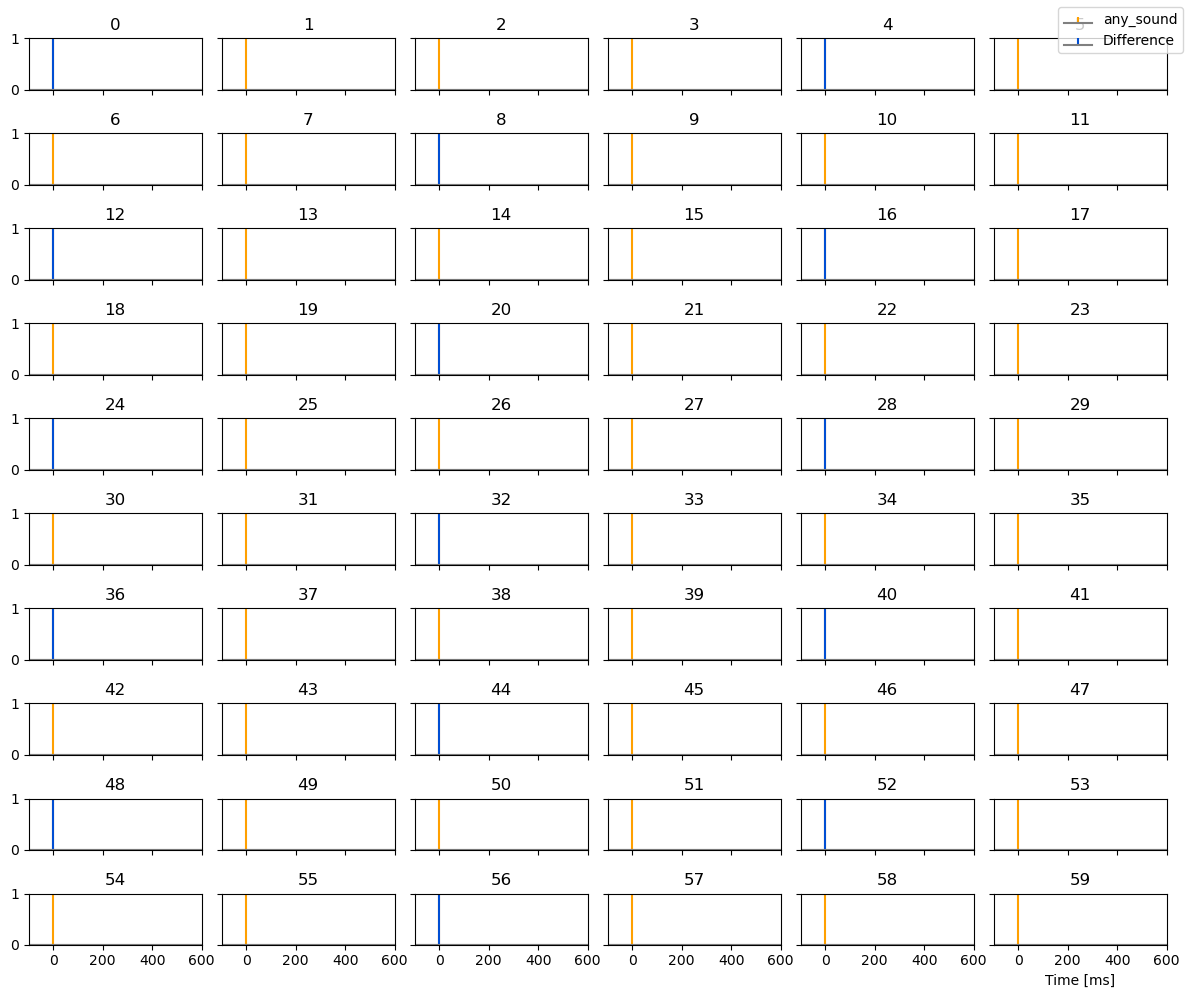

In [4]:
any_sound = epoch_impulse_predictor('eeg', 1, ds=ds, name='any_sound')

diff_code = Var.from_dict(ds['condition'], {'Standard': 1, 'Deviant': 0, 'Looming': 0, 'Receding': 0})
diff = epoch_impulse_predictor('eeg', diff_code, ds=ds, name='Difference')

p = plot.UTS([any_sound, diff], '.case', stem=True)

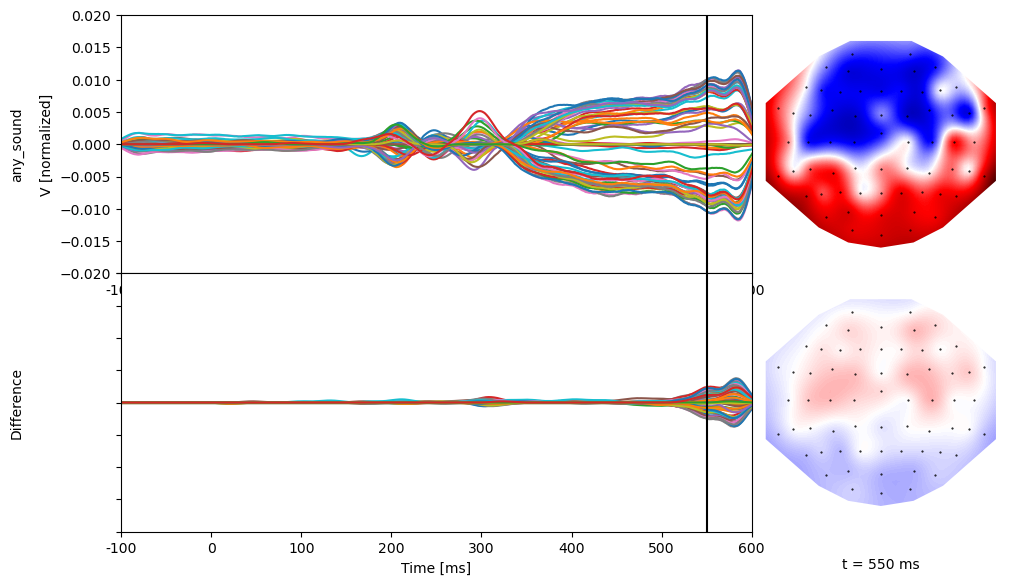

In [5]:
fit = boosting('eeg', [any_sound, diff], -0.1, 0.6, basis=0.050, ds=ds, model='condition', partitions=2, delta=0.01)
p = plot.TopoButterfly(fit.h, xlim=(-0.100, 0.600), t=0.550)